<a href="https://colab.research.google.com/github/EhsanNikpey/machine-learning-fundamentals/blob/main/kalman_filter_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STATISTICAL LEARNING AND NEURAL NETWORKS, A.A. 2022/2023**

**COMPUTER LAB 4** - Kalman filter

**Duration: 3 hours**

**Introduction:**

In this lab, you are provided with the set of coordinates (x,y – horizontal and vertical) describing the trajectories of pedestrians moving acrooss a scene. Your task is to simulate the observed positions of the pedestrians by adding observation noise, then to track the subjects using a Kalman filter. In other words, you need to estimate the next (x,y) positions, from the observations of the previous positions.


*Simulating the observed coordinates*

Choose one of the trajectories in the dataset. This data will be considered the real trajectory. Generate the observed directory by adding observation noise $\delta_t \sim\ \mathcal{N}(0,\sigma^{2}_{R})\$ to the (x,y) coordinates.


*Designing the Kalman filter*

Your task is to **design a Kalman filter** based on a constant velocity model, which tracks the next (x,y) position of the object, from the observation of the previous positions. The code must be based on the following model.

*   The state vector contains coordinates and velocities: $z^{T}_{t} = (z_{1t}, z_{2t}, v_{1t}, v_{2t})$ (see slides). The object has initial coordinates (0,0) and velocity $(\Delta,Δ)$.
*   Only the coordinates (but not the velocities) are observed. This leads to a linear dynamical system with:

$A = \left( \begin{matrix} 1 & 0 & \Delta & 0 \\ 0 & 1 & 0 & \Delta \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{matrix} \right)$


$C = \left( \begin{matrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{matrix} \right)$

and B = D = 0.

*   $\Sigma_{Q}$, and $\Sigma_{R}$ should be set to:

$\Sigma_{Q} = \sigma^{2}_{Q}\left( \begin{matrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{matrix} \right)$

$\Sigma_{R} = \sigma^{2}_{R}\left( \begin{matrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{matrix} \right)$

To see if your Kalman filter is working well, you should plot the estimated position of the object over time with respect to the true position (i.e., the first two entries of the state vector) and the observed position. Depending on the chosen parameters, for each coordinate the graph may look something like this:

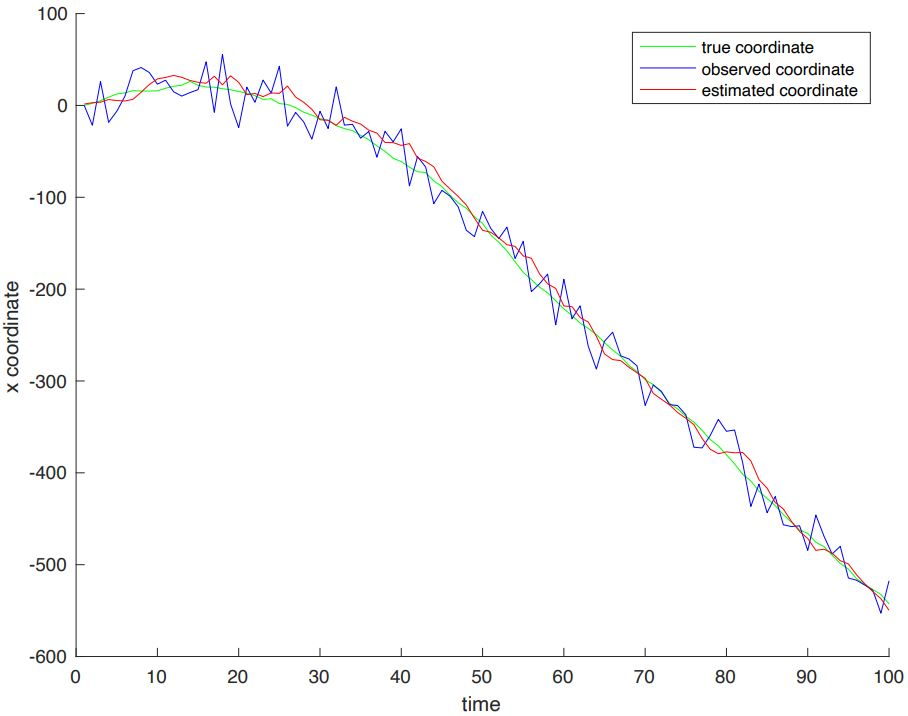

**Suggestion**: when implementing your Kalman filter, you will have to choose initial values for **$\mu_{t}$** and **$\Sigma_{t}$**. Provided that you do not make very unreasonable assumptions, the Kalman filter will update those estimates from observed data, so the initial choices are not very critical.

Test your Kalman filter modifying the values of some of the parameters, including standard deviations **$\sigma_{Q}$** and **$\sigma_{R}$**, initial values for **$\mu_{t}$** and **$\Sigma_{t}$** and the value of **$\Delta$**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ndjson

Mounted at /content/drive


In [ ]:
import ndjson
import pandas as pd
import numpy as np

#Dataset origin: https://paperswithcode.com/dataset/trajnet-1
#The crowds_students001 file is loaded, and formatted as a list of numpy vectors

with open('/content/drive/MyDrive/crowds_students001_trackonly.ndjson') as f:
  data = ndjson.load(f)
p='-1'

person_dict = []

for ii in range(len(data)):
  if(p!=data[ii]['track']['p']):
    p=data[ii]['track']['p']
    person_dict.append([])
  person_dict[p].append((data[ii]['track']['x'],data[ii]['track']['y']))

person_dict_numpy = []
for ii in range(148):
  person_dict_numpy.append(np.array(person_dict[ii], dtype=float))

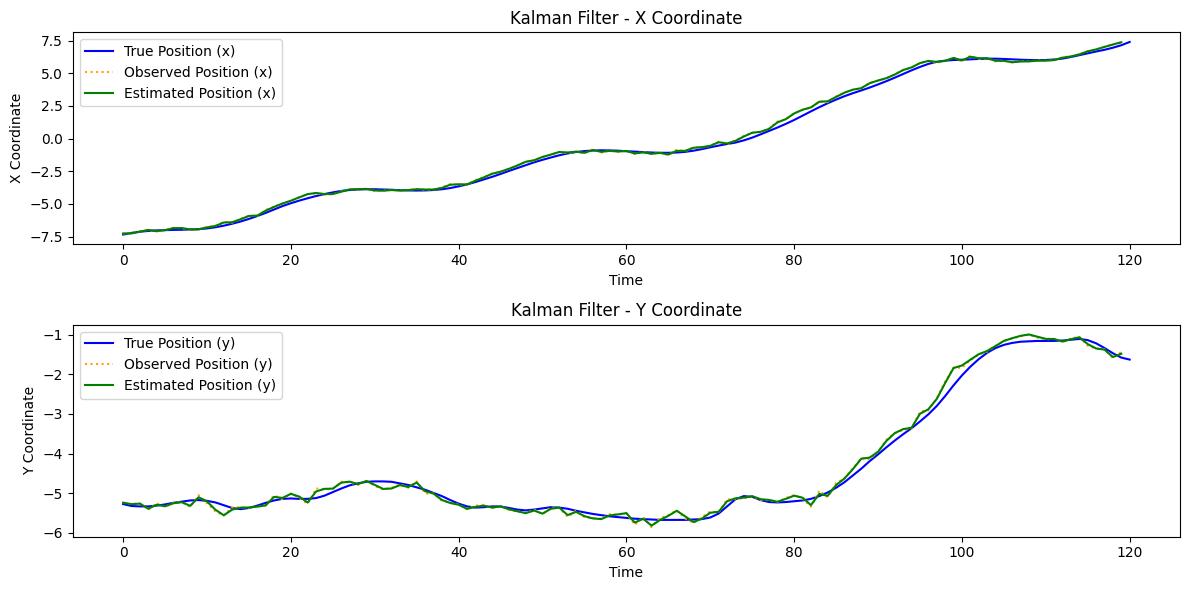

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Implement the Kalman filter as a function using the numpy library
def kalman_filter(y, mu_tmin1, sigma_tmin1, A, C, Q, R):
  # Prediction Step
  mu_pred = A @ mu_tmin1  # \mu_{t|t-1} = A_t \mu_{t-1}
  sigma_pred = A @ (sigma_tmin1 @ A.T) + Q  # \Sigma_{t|t-1} = A_t \Sigma_{t-1} A_t^T + Q_t
  # Kalman Gain
  K = sigma_pred @ (C.T @ np.linalg.inv(C @ (sigma_pred @ C.T) + R))
  # Update Step
  y_pred = C @ mu_pred  # \hat{y}_t = C_t \mu_{t|t-1}
  r = y - y_pred  # r_t = y_t - \hat{y}_t
  mu_est = mu_pred + (K @ r)  # \mu_t = \mu_{t|t-1} + K_t r_t
  sigma_est = (np.eye(len(K)) - (K @ C)) @ sigma_pred  # \Sigma_t = (I - K_t C_t) \Sigma_{t|t-1}
  return mu_est, sigma_est
# Select a random trajectory
ture_positions = person_dict_numpy[100]  # it define the person we want to track of
# Define the time step delta
Delta = 1.0
'''
If Delta is increased, Kalman Filter assumes greater motion between observations
If it decrease Kalman assume that less time passed between observations
'''
# Define the state transition matrix A
A = np.array([[1, 0, Delta, 0],
              [0, 1, 0, Delta],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])
# Define the measurement matrix C
C = np.array([[1, 0, 0, 0],  # x is measured directly
              [0, 1, 0, 0]]) # y is measured directly
# Set the standard deviation of the measurement noise
sigma_R = 0.1  #it define the measurement noise. if we increase it the kalman filter assume measurement are less reliable
sigma_Q = 0.1 # it define process noise. if we increase it the kalman filter assume that system is less predictable
# Define the process noise covariance matrix
Q = (sigma_Q**2) * np.eye(4)
# Define the measurement noise covariance matrix
R = (sigma_R**2) * np.eye(2)
# Set the initial state and covariance
mu_0 = np.array([true_positions[0][0], true_positions[0][1], 0, 0]) # Initial state estimate
sigma_0 = np.eye(4)  # Initial state covariance
# Prepare lists to store results
estimated_positions = []
observed_positions = []
# Initialize the state and covariance
mu_t = mu_0
sigma_t = sigma_0
# Iterate over the observed coordinates
for t in range(1, len(true_positions)):
  # Get the observed coordinates at time t with added Gaussian noise
  y = true_positions[t] + np.random.normal(0, sigma_R, 2)
  observed_positions.append(y)
  # Apply the Kalman filter on the observed coordinates
  mu_t, sigma_t = kalman_filter(y, mu_t, sigma_t, A, C, Q, R)
  estimated_positions.append(mu_t[:2])
# Convert results to numpy arrays for plotting
estimated_positions = np.array(estimated_positions)
observed_positions = np.array(observed_positions)
# Plot the results
plt.figure(figsize=(12, 6))
# Plot x-coordinate over time
plt.subplot(2, 1, 1)
plt.plot([pos[0] for pos in true_positions], label="True Position (x)", color="blue")
plt.plot([pos[0] for pos in observed_positions], label="Observed Position (x)", color="orange", linestyle="dotted")
plt.plot([pos[0] for pos in estimated_positions], label="Estimated Position (x)", color="green")
plt.xlabel("Time")
plt.ylabel("X Coordinate")
plt.legend()
plt.title("Kalman Filter - X Coordinate")
# Plot y-coordinate over time
plt.subplot(2, 1, 2)
plt.plot([pos[1] for pos in true_positions], label="True Position (y)", color="blue")
plt.plot([pos[1] for pos in observed_positions], label="Observed Position (y)", color="orange", linestyle="dotted")
plt.plot([pos[1] for pos in estimated_positions], label="Estimated Position (y)", color="green")
plt.xlabel("Time")
plt.ylabel("Y Coordinate")
plt.legend()
plt.title("Kalman Filter - Y Coordinate")
plt.tight_layout()
plt.show()

The Kalman filter effectively tracks the true trajectory of a pedestrian by smoothing out noisy observations. The true positions (blue line) represent the actual trajectory, while the observed positions (orange dotted line) are derived by adding Gaussian noise, highlighting measurement uncertainties. The estimated positions (green line) predicted by the Kalman filter closely follow the true trajectory, demonstrating its ability to reduce noise and improve accuracy. Initially, there may be slight discrepancies as the filter adjusts, but it quickly converges to the true path. The results show that the filter performs well when process noise (σ Q) and measurement noise (σ R) are appropriately calibrated.

Mathematically, the Kalman filter balances predictions and noisy observations through its prediction and update steps. The state transition matrix (A) and noise covariance matrices (Q,R) govern the system's predictability and measurement reliability. Adjusting these parameters impacts performance: higher
σ R
reduces reliance on observations, while higher σ Q
  accounts for greater unpredictability. The plots confirm the Kalman filter's capability to smooth trajectories while remaining responsive to significant changes in observations, making it a robust tool for tracking in noisy environments.